# EDA específico: relación entre variables y cancelación

Este notebook corresponde a la parte de Persona 2. Su objetivo es analizar el balance de `is_canceled`, estudiar relaciones descriptivas entre algunas variables y el target, y detectar posibles fugas de información.

No sustituye al EDA general, no decide el tratamiento de nulos o duplicados y no aplica técnicas de balanceo.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
pd.set_option("display.max_rows", 100)

DATA_PATH = Path("data/raw/dataset_practica_final.csv")
TARGET = "is_canceled"
LEAKAGE_COLUMNS = {"reservation_status", "reservation_status_date"}
IDENTIFIER_COLUMNS = {"agent", "company"}

## 1. Carga y validación del target

Antes de analizarlo comprobamos que el target existe, no tiene nulos y contiene exactamente las clases binarias `0` y `1`.

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"No se encontró el dataset en {DATA_PATH.resolve()}")

df = pd.read_csv(DATA_PATH)

if TARGET not in df.columns:
    raise KeyError(f"El dataset no contiene el target {TARGET!r}.")
if df[TARGET].isna().any():
    raise ValueError("El target contiene valores nulos.")
if set(df[TARGET].unique()) != {0, 1}:
    raise ValueError("El target debe contener exactamente las clases 0 y 1.")

print(f"Filas: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"Target validado: {TARGET}")

Filas: 119,390
Columnas: 32
Target validado: is_canceled


## 2. Balance de clases

La clase `1` representa una reserva cancelada. Medimos cantidades, porcentajes y la relación entre la clase mayoritaria y la minoritaria antes de valorar si el desbalance puede afectar a la evaluación.

In [3]:
target_summary = (
    df[TARGET]
    .value_counts()
    .sort_index()
    .rename_axis("class")
    .to_frame("count")
)
target_summary["percentage"] = (
    target_summary["count"] / len(df) * 100
).round(2)

majority_count = target_summary["count"].max()
minority_count = target_summary["count"].min()
imbalance_ratio = majority_count / minority_count

display(target_summary)
print(f"Relación clase mayoritaria/minoritaria: {imbalance_ratio:.2f}:1")

,count,percentage
class,,
0,75166,62.96
1,44224,37.04


Relación clase mayoritaria/minoritaria: 1.70:1


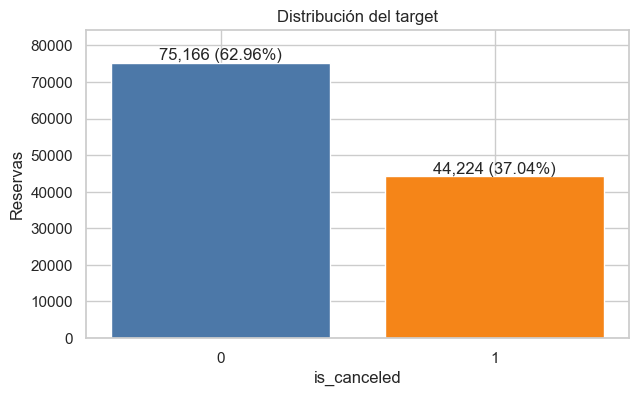

In [4]:
plot_data = target_summary.reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    plot_data["class"].astype(str),
    plot_data["count"],
    color=["#4C78A8", "#F58518"],
)

for bar, percentage in zip(bars, plot_data["percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,} ({percentage:.2f}%)",
        ha="center",
        va="bottom",
    )

ax.set(title="Distribución del target", xlabel="is_canceled", ylabel="Reservas")
ax.set_ylim(0, plot_data["count"].max() * 1.12)
plt.show()

### Interpretación

Existe un desbalance moderado: la clase `0` es mayoritaria, pero la clase `1` sigue teniendo una representación considerable. Por este motivo no aplicamos automáticamente SMOTE, undersampling, oversampling ni `class_weight`. Accuracy se informará, pero deberá acompañarse de precision, recall, F1 y ROC-AUC.

## 3. Relación entre variables numéricas y target

La correlación con un target binario permite detectar relaciones lineales preliminares. Excluimos `agent` y `company` porque son identificadores: tratarlos como cantidades continuas produciría una interpretación engañosa.

Este análisis es descriptivo. No implica causalidad, no captura relaciones no lineales y no se utilizará por sí solo para eliminar variables.

In [5]:
numeric_columns = [
    column
    for column in df.select_dtypes(include="number").columns
    if column not in {TARGET, *IDENTIFIER_COLUMNS}
]

numeric_relationships = (
    df[numeric_columns]
    .corrwith(df[TARGET])
    .dropna()
    .rename("correlation_with_target")
    .to_frame()
)
numeric_relationships["absolute_correlation"] = (
    numeric_relationships["correlation_with_target"].abs()
)
top_numeric_relationships = numeric_relationships.sort_values(
    "absolute_correlation",
    ascending=False,
).head(10)

display(top_numeric_relationships.round(3))

,correlation_with_target,absolute_correlation
lead_time,0.293,0.293
total_of_special_requests,-0.235,0.235
required_car_parking_spaces,-0.195,0.195
booking_changes,-0.144,0.144
previous_cancellations,0.110,0.110
is_repeated_guest,-0.085,0.085
adults,0.060,0.060
previous_bookings_not_canceled,-0.057,0.057
days_in_waiting_list,0.054,0.054
adr,0.048,0.048


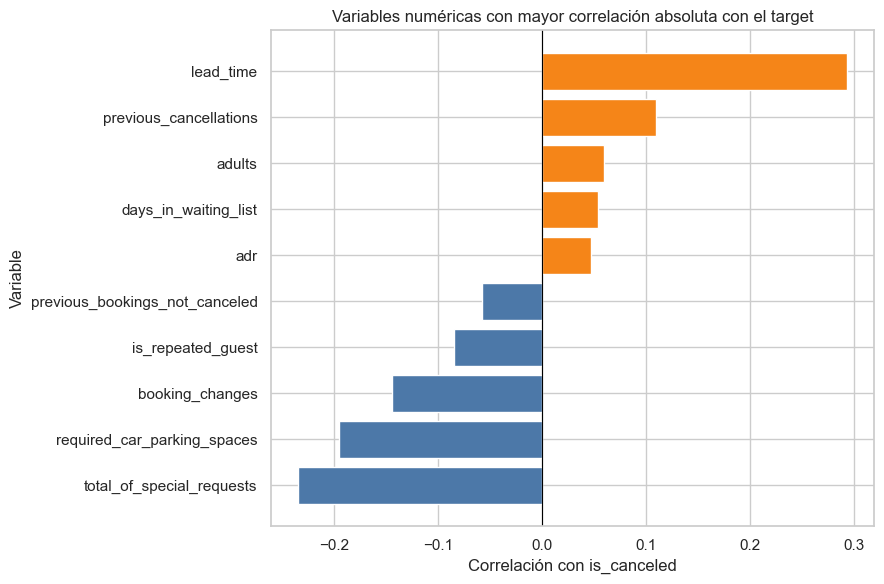

In [6]:
plot_numeric = top_numeric_relationships.sort_values("correlation_with_target")
colors = [
    "#F58518" if value > 0 else "#4C78A8"
    for value in plot_numeric["correlation_with_target"]
]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    plot_numeric.index,
    plot_numeric["correlation_with_target"],
    color=colors,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set(
    title="Variables numéricas con mayor correlación absoluta con el target",
    xlabel="Correlación con is_canceled",
    ylabel="Variable",
)
plt.tight_layout()
plt.show()

## 4. Relación entre variables categóricas y target

Comparamos la tasa media de cancelación en categorías interpretables. Una tasa más alta significa que una mayor proporción de las reservas de esa categoría terminó cancelada. Las diferencias son asociaciones descriptivas, no causas demostradas.

In [7]:
CATEGORICAL_FEATURES = [
    "hotel",
    "market_segment",
    "deposit_type",
    "customer_type",
]

missing_features = [
    feature for feature in CATEGORICAL_FEATURES if feature not in df.columns
]
if missing_features:
    raise KeyError(f"Faltan variables categóricas esperadas: {missing_features}")

def cancellation_rate_by_category(data, feature):
    return (
        data.groupby(feature, dropna=False)[TARGET]
        .agg(cancellation_rate="mean", observations="size")
        .assign(cancellation_percentage=lambda table: table["cancellation_rate"] * 100)
        .sort_values("cancellation_rate", ascending=False)
    )

categorical_tables = {
    feature: cancellation_rate_by_category(df, feature)
    for feature in CATEGORICAL_FEATURES
}

for feature, table in categorical_tables.items():
    print(f"Tasa de cancelación por {feature}")
    display(table[["observations", "cancellation_percentage"]].round(2))

Tasa de cancelación por hotel


,observations,cancellation_percentage
hotel,,
City Hotel,79330,41.73
Resort Hotel,40060,27.76


Tasa de cancelación por market_segment


,observations,cancellation_percentage
market_segment,,
Undefined,2,100.00
Groups,19811,61.06
Online TA,56477,36.72
Offline TA/TO,24219,34.32
Aviation,237,21.94
Corporate,5295,18.73
Direct,12606,15.34
Complementary,743,13.06


Tasa de cancelación por deposit_type


,observations,cancellation_percentage
deposit_type,,
Non Refund,14587,99.36
No Deposit,104641,28.38
Refundable,162,22.22


Tasa de cancelación por customer_type


,observations,cancellation_percentage
customer_type,,
Transient,89613,40.75
Contract,4076,30.96
Transient-Party,25124,25.43
Group,577,10.23


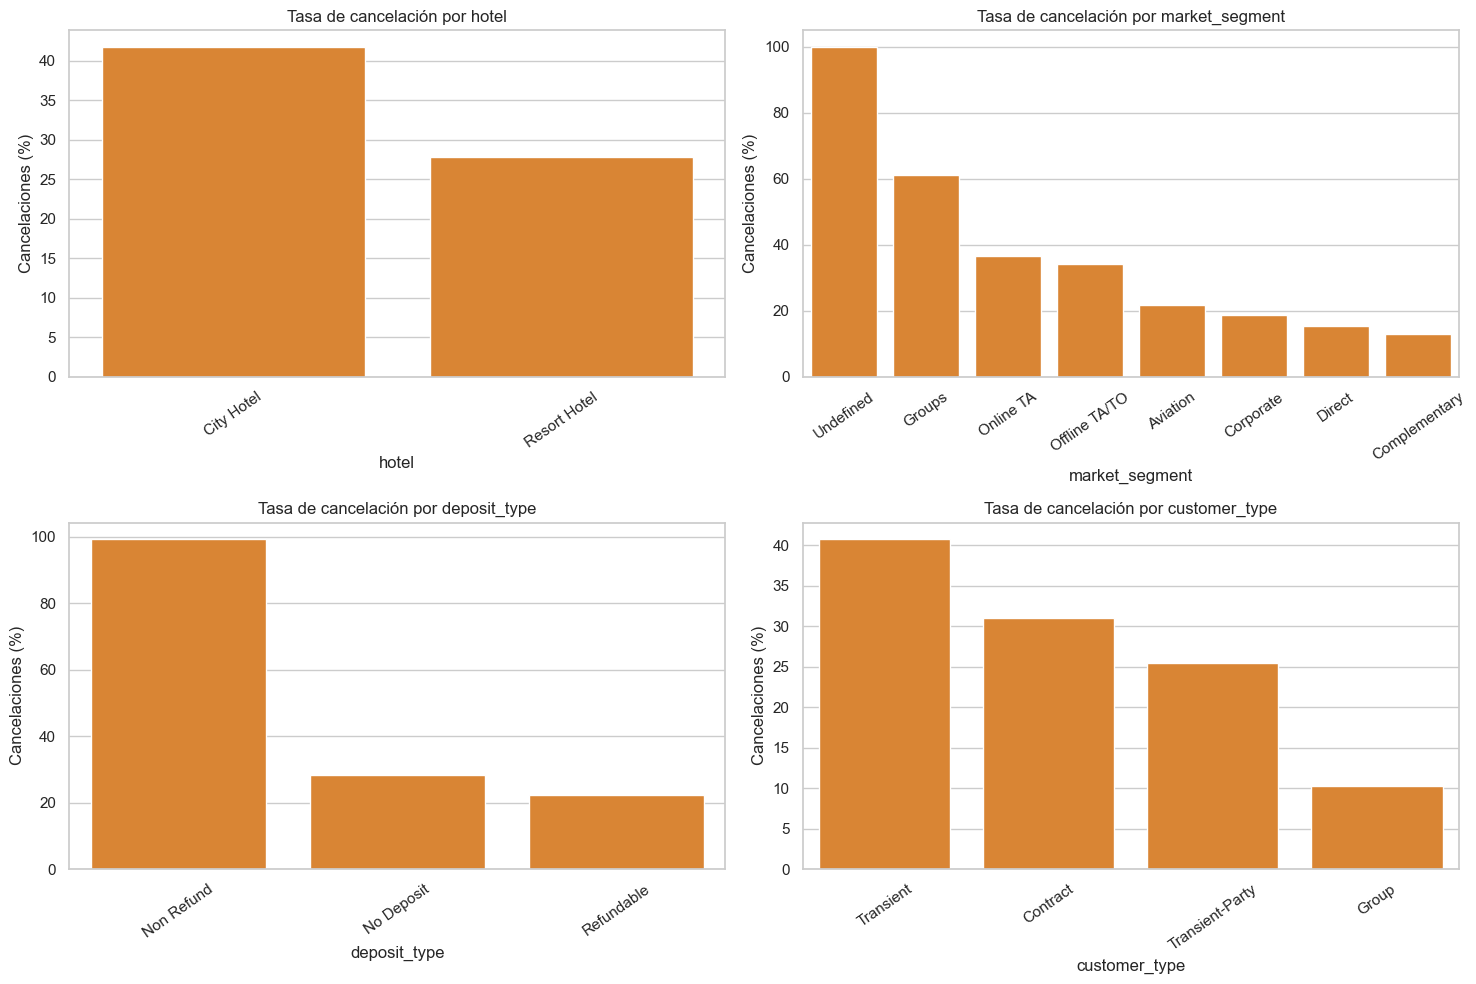

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, feature in zip(axes.flat, CATEGORICAL_FEATURES):
    plot_table = categorical_tables[feature].reset_index()
    sns.barplot(
        data=plot_table,
        x=feature,
        y="cancellation_percentage",
        color="#F58518",
        ax=ax,
    )
    ax.set(
        title=f"Tasa de cancelación por {feature}",
        xlabel=feature,
        ylabel="Cancelaciones (%)",
    )
    ax.tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

### Precaución con categorías pequeñas

Los porcentajes deben interpretarse junto con `observations`. Por ejemplo, `market_segment = Undefined` tiene una tasa observada del 100 %, pero solo contiene 2 reservas; no aporta evidencia suficiente para generalizar. Del mismo modo, las categorías poco frecuentes pueden producir porcentajes extremos e inestables.

## 5. Comprobación de fuga de información

`reservation_status` describe el estado final de la reserva. Si identifica directamente si hubo cancelación, utilizarla como entrada permitiría al modelo conocer de antemano la respuesta que debe predecir.

In [9]:
for column in LEAKAGE_COLUMNS:
    if column not in df.columns:
        raise KeyError(f"No se encontró la columna esperada {column!r}.")

reservation_status_table = pd.crosstab(
    df["reservation_status"],
    df[TARGET],
    margins=True,
)
display(reservation_status_table)

status_target_pairs = (
    df.groupby("reservation_status")[TARGET]
    .agg(["min", "max", "count"])
)
display(status_target_pairs)

is_canceled,0,1,All
reservation_status,,,
Canceled,0,43017,43017
Check-Out,75166,0,75166
No-Show,0,1207,1207
All,75166,44224,119390


,min,max,count
reservation_status,,,
Canceled,1,1,43017
Check-Out,0,0,75166
No-Show,1,1,1207


### Interpretación del leakage

Cada valor de `reservation_status` queda asociado a una única clase del target: `Check-Out` aparece con `0`, mientras que `Canceled` y `No-Show` aparecen con `1`. Por tanto, `reservation_status` debe excluirse. `reservation_status_date` también debe excluirse porque registra información temporal asociada al desenlace de la reserva.

## 6. Conclusiones

- El target es binario y no contiene valores nulos.
- Existe un desbalance moderado, por lo que accuracy no debe interpretarse de forma aislada.
- Precision, recall, F1 y ROC-AUC complementarán la evaluación.
- Algunas variables presentan asociaciones descriptivas con la cancelación, pero esto no demuestra causalidad ni sustituye la importancia obtenida posteriormente con Random Forest.
- `reservation_status` y `reservation_status_date` deben excluirse para evitar data leakage.
- No aplicamos ninguna técnica de balanceo en esta fase. Cualquier técnica futura se aplicaría solo sobre train y se compararía mediante validación.
- La métrica principal definitiva queda pendiente del coste de falsos positivos y falsos negativos.